# CATS AND DOGS

In the proccess of this project we will discuss the quality of various Neural Network models to analyse and Classify a Dataset of 37 types of cat and dog races. This short study will be done using a Dataset provided by Oxford University called : Oxford-IIIT Pet Dataset. 

The project is divided in 5 different steps :

- Exploration of the Dataset
- Binary Classification between cats and dogs
- Classification between 37 cat and dog races
- Animal Segmentation
- Comparative Analyses

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Introduction : étude de l'ensemble des données
<p>Images de chats et de chiens issues du jeu de données <i>OxfordIIITPet</i></p>
<p>Categories binaires : Chat / Chien</p>
<p>Classes : 37 races de chats et de chiens</p>

In [13]:
datapath = '../data/data_cats_and_dogs'

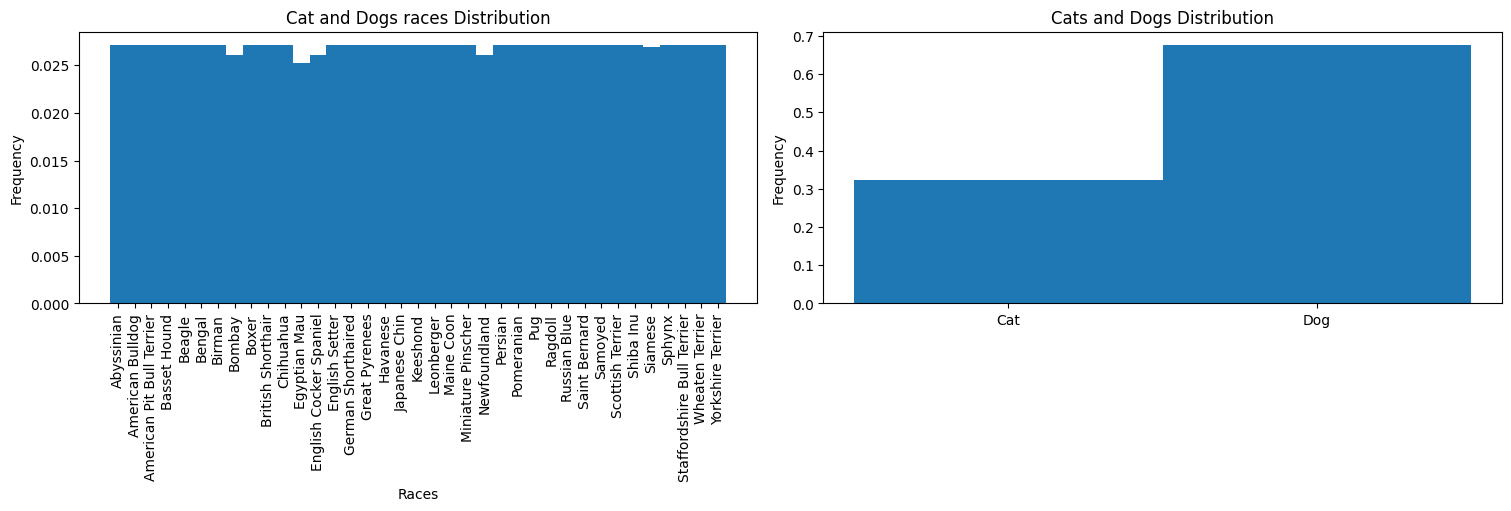

In [14]:
transform = torchvision.transforms.ToTensor()
dataset = torchvision.datasets.OxfordIIITPet(root=datapath, target_types="binary-category", download=True, transform=transform)

def get_data_statistics(dataset):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), layout="constrained")

    axes[0].hist(dataset._labels, bins=np.arange(38)-0.5, density=True)
    axes[0].set_title('Cat and Dogs races Distribution')
    axes[0].set_xlabel('Races')
    axes[0].set_xticks(np.arange(37))
    axes[0].set_xticklabels(list(dataset.classes))
    axes[0].set_ylabel('Frequency')
    axes[0].tick_params(axis='x', rotation=90)
    
    axes[1].hist(dataset._bin_labels, bins=np.arange(3)-0.5, density=True)
    axes[1].set_title('Cats and Dogs Distribution')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(list(dataset.bin_classes))
    axes[1].set_ylabel('Frequency')
    plt.show()

get_data_statistics(dataset)

Il y a nettement plus d'images de chiens que de chats</p>
Les 37 races sont globalement équilibrées

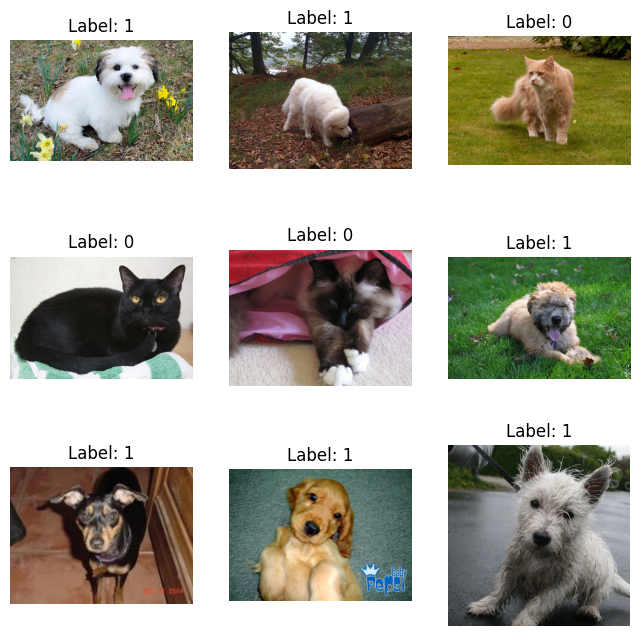

In [15]:
# Plot 9 random images from the MNIST train dataset
def plot_images(img_dataset, RGB='True'):
    """Plots 9 random images from the given dataset

    Args:
        img_dataset (torch.utils.data.Dataset): The dataset to plot images from
    """
    # Set up a 3x3 grid for plotting 9 random images
    figure = plt.figure(figsize=(8, 8))
    cols, rows = 3, 3
    
    # Plot 9 random images from the img_dataset
    for i in range(1, cols * rows + 1):
        random_idx = torch.randint(len(img_dataset), size=(1,)).item()  # Pick a random index
        img, label = img_dataset[random_idx]  # Get the image and its label
        figure.add_subplot(rows, cols, i)  # Add subplot
        plt.title(f'Label: {label}')  # Set title to show the label
        plt.axis("off")  # Turn off axis
        if RGB == 'True':
            plt.imshow(torch.permute(img.squeeze(),(1,2,0)))  # Plot image
        else:
            plt.imshow(img.squeeze())  # Plot image
    
    plt.show()  # Display the figure

plot_images(dataset)

Biais visuels possibles :</p>
Animaux parfois entiers, parfois coupés, luminosité parfois mauvaise, la résolution est bonne mais nous devrons probablement la dégrader pour pouvoir entrainer un CNN. La taille des images devra être modifiée pour qu'elles aient toutes les mêmes dimensions

In [16]:
dataset

Dataset OxfordIIITPet
    Number of datapoints: 3680
    Root location: ../data/data_cats_and_dogs
    StandardTransform
Transform: ToTensor()

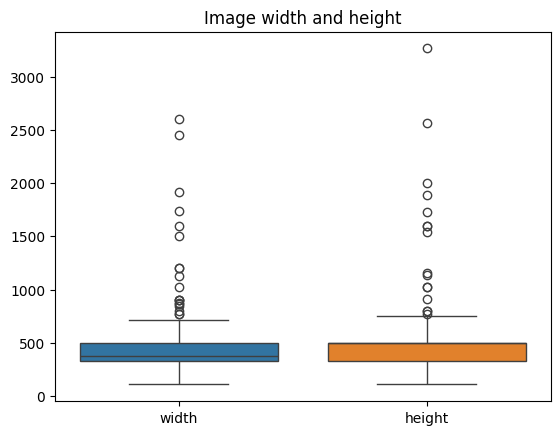

In [17]:
# ANALYSE OF THE IMAGES SIZES

img_sizes = []
for i in range(3680):
    img, _ = dataset[i]
    img_sizes.append([np.shape(img)[1], np.shape(img)[2]])

import seaborn as sns
plt.figure()
ax = sns.boxplot(np.array(img_sizes))
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(['width', 'height'])
plt.title("Image width and height")
plt.show()

In [18]:
print(f'mean width: {int(np.mean(img_sizes))}, mean height: {int(np.mean(img_sizes))}')

mean width: 407, mean height: 407


The mean value may be to high to train the model efficiently, it will probably be choosen lower than 407 at the end to train the model

In [19]:
## FONCTION D'IMPORTATION DES DONNEES choix de la taille des images, de la taille du batch et de la catégorie (espèce, race ou segmentation)

def get_datasets_loaders(batch_size, target_types:str="binary-category", size=(100, 100), norm_like_ImageNet=False):
    """_gets datasets and dataloaders for the OxfordIIIPet dataset depending on the targeted labels (binary, multi-class or segmentation)_

    Args:
        batch_size (int): batch size
        target_types (str): _
            "binary-category" : cats / dogs, 
            "category" : cats and dogs races, 
            "segmentation" : PIL image segmentation trimap of the images
        resize (bool): resize the images
        size (tuple): resize the images with this size_.
    """
    transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size),
                                                    torchvision.transforms.ToTensor()])
    # pour normaliser les images comme ImageNet (fine-tunning VGG16 ou ResNet18)
    if norm_like_ImageNet == True:
        transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size),
                                                    torchvision.transforms.ToTensor(),
                                                    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]) # recommended for VGG16 or ResNet18 cf Doc
    
    # chargement des datasets cas classification binaire ou multi-classes
    if target_types != 'segmentation':
        train_dataset = datasets.OxfordIIITPet(root=datapath, split="trainval", target_types=target_types, transform=transform, download=True) #transform=transform,
        test_dataset = datasets.OxfordIIITPet(root=datapath, split="test", target_types=target_types, transform=transform, download=True) #transform=transform

    # chargement des datasets pour la segmentation
    elif target_types == 'segmentation':
        # fonction pour transformer les masques en tenseurs composés de valeurs entières 0, 1, 2 (animal, fond, contour)
        def mask_transform(mask):

            mask = mask.resize(size, Image.NEAREST)
            mask_np = np.array(mask)
            # Si les valeurs sont dans [0, 1], on les remet sur 0, 1, 2
            uniques = np.unique(mask_np)
            # Mappe les valeurs uniques à 0, 1, 2
            mask_int = np.searchsorted(uniques, mask_np)
            return torch.from_numpy(mask_int).long()

        target_transform = mask_transform

        train_dataset = datasets.OxfordIIITPet(root=datapath, split="trainval", target_types=target_types, transform=transform, target_transform=target_transform, download=True) #transform=transform,
        test_dataset = datasets.OxfordIIITPet(root=datapath, split="test", target_types=target_types, transform=transform, target_transform=target_transform, download=True) #transform=transform

    train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

    return train_dataset, test_dataset, train_loader, test_loader

<p>La fonction <i>get_datasets_loaders</i> a pour but de charger les datasets et les data loaders en fonction de la taille du batch et de la tâche à réaliser, classification binaire ('binary-category'), classification multipple ('category') et segmentation ('segmentation').</p>
<p><i>transform</i> et <i>target_transform</i> appliquent des transformations respectivement aux images et aux labels des datasets. </p>
<p>Pour la segmentation, les masques (labels) sont transformés afin qu'ils soient constitués de valeurs comprises dans (0, 1, 2) (animal, background, limite) c'est la fonction <b>mask_transform</b> qui réalise cela. Cette étape est nécessaire pour l'utilisation de la fonction loss cross entropy lors de l'entrainement. La méthodde <i>ToTensor</i> plus simple créee un tenseur avec des valeurs non entières ce qui ne convient pas lors de l'utilisation de la cross entropy.</p>

In [20]:
def plot_losses(saved_losses):
    plt.plot(saved_losses['train'],label='train loss')
    plt.plot(saved_losses['val'],label='validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

## Part 1 : Classification binaire
#### Transfer-learning et fine tuning de ResNet18
<p> ResNet18 est connu comme étant un excellent modèle de classification, on suppose donc que sa base convolutive entrainée sur ImageNet a déjà acquis de très bonnes features extraites des images. L'objectif ici est d'utiliser ces features et de modeler la tête classifiante selon le nombre de catégories  que l'on souhaite avoir en sortie du modèle.</p>

<p>Nous avons commencé par entrainer VGG16 mais les résultats obtenus étant mitigés nous avons plutôt continué avec ResNet18</p>

In [21]:
# GENERAL FUNCTION TO TRAIN A MODEL
def train(model, dataloaders, dataset_sizes, optimizer, criterion, num_epochs, path, device='cuda'):

    model.to(device)
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            running_loss = 0.0

            with torch.set_grad_enabled(phase == 'train'):
                for imgs, masks in dataloaders[phase]:

                    imgs = imgs.to(device)
                    masks = masks.to(device)
                    # squeeze le mask si besoin (normalement il n'y en a plus besoin)
                    if masks.ndim == 4 and masks.shape[1] == 1:
                        masks = masks.squeeze(1)

                    if phase == 'train':
                        optimizer.zero_grad()
                    outputs = model(imgs)
                    loss = criterion(outputs, masks.long()) # CrossEntropy est appliquée à des masks composés de valeurs entières (ici 0, 1, 2)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                    running_loss += loss.item() * imgs.size(0)

            epoch_loss = running_loss / dataset_sizes[phase]

            if phase == 'train':
                train_losses.append(epoch_loss)
            else:
                val_losses.append(epoch_loss)

            print(f"{phase} Loss: {epoch_loss:.4f}")
            
    saved_losses = {'train': train_losses, 'val': val_losses}        
    path_model = path
    torch.save(model.state_dict(), path_model)

    return model, saved_losses

# MORE COMPLETE FUNCTION TO TRAIN A MODEL WITH LEARNING RATE SCHEDULER AND BEST MODEL SAVING
def train_schdl(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler, path, num_epochs=10):
    """ function to train a model
        Author: from a blog post of Sasank Chilamkurthy
        License: BSD, Revised

    Args:
        model : the model to train
        dataloaders : dictionary containing the training and validation dataloaders
        dataset_sizes : dictionary containing the sizes of the training and validation datasets
        criterion : loss function
        optimizer : depends on the model and the training task
        scheduler : enables to adjust the learning rate during training
        path : path to save the best model parameters
        num_epochs : number of epochs. Defaults to 25.

    Returns:
        trained model
    """
    since = time.time()

    saved_losses = {'train': [], 'val': []}
    
    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        path_model = path

        torch.save(model.state_dict(), path_model)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                saved_losses[phase].append(epoch_loss)
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), path_model)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(path_model, weights_only=True))
    return model, saved_losses

Première approche, transfert learning de la couche linéaire de sortie de ResNet18 en figeant les blocks de convolution, puis fine tuning du modèle complet avec un learning rate très faible

In [22]:
def fine_tune_ResNet18(model, dataloaders, dataset_sizes, optimizer=optim.Adam, criterion=nn.CrossEntropyLoss(), num_epochs=5, learning_rate_1=0.001, learning_rate_2=0.0001):

    # Transfert learning de la couche linéaire de sortie (ResNet a une seule couche linéaire en sortie)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True

    optimizer_ft = optimizer(params=model.fc.parameters(), lr=learning_rate_1)

    model, saved_losses = train(model, dataloaders, 
                                         dataset_sizes, 
                                         optimizer_ft, 
                                         criterion, 
                                         num_epochs=num_epochs,
                                         path='restnet_ft0_binary.pt')

    # fine tunning du modèle complet
    for param in model.parameters():
        param.requires_grad = True

    optimizer_ft = optimizer(model.parameters(), lr=learning_rate_2)

    model, saved_losses = train(model, dataloaders, 
                                         dataset_sizes, 
                                         optimizer_ft, 
                                         criterion, 
                                         num_epochs=num_epochs,
                                         path='restnet_ft0_binary.pt')
    
    return model, saved_losses

Epoch 1/5
train Loss: 0.3131
val Loss: 0.1254
Epoch 2/5
train Loss: 0.1103
val Loss: 0.0863
Epoch 3/5
train Loss: 0.0848
val Loss: 0.0724
Epoch 4/5
train Loss: 0.0685
val Loss: 0.0622
Epoch 5/5
train Loss: 0.0610
val Loss: 0.0603
Epoch 1/5
train Loss: 0.0476
val Loss: 0.0495
Epoch 2/5
train Loss: 0.0094
val Loss: 0.0298
Epoch 3/5
train Loss: 0.0019
val Loss: 0.0238
Epoch 4/5
train Loss: 0.0017
val Loss: 0.0270
Epoch 5/5
train Loss: 0.0012
val Loss: 0.0211


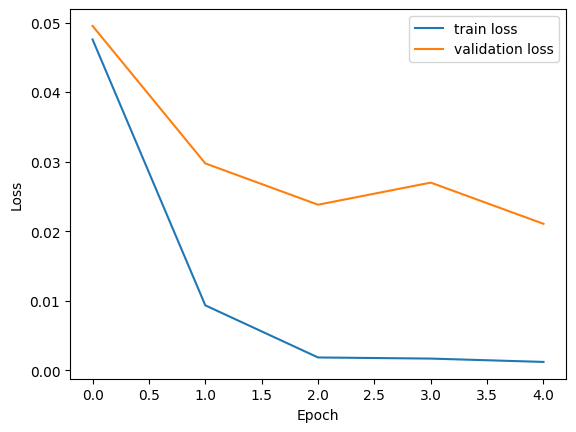

In [7]:
num_classes = 2 # binary classification cats / dogs
batch_size = 60

img_width, img_height = 224, 224 # recommandé pour VGG16, taille de IMAGENET dataset ayant entrainé vgg16
size = (img_width, img_height)

train_dataset, test_dataset, train_loader, test_loader = get_datasets_loaders(batch_size, target_types="binary-category", size=size, norm_like_ImageNet=True)
dataloaders = {'train': train_loader, 'val': test_loader}
dataset_sizes = {'train' : len(train_dataset) , 'val': len(test_dataset)}

model_ft = models.resnet18(weights='IMAGENET1K_V1')  # pré-entrainé sur ImageNet
num_ftrs = model_ft.fc.in_features

model_ft.fc = nn.Linear(num_ftrs, num_classes) # modification de la couche de sortie pour classification binaire cats / dogs

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss(reduction='mean') # d'après le TP sur l'explainability

model, saved_losses = fine_tune_ResNet18(model_ft, dataloaders, dataset_sizes, criterion=criterion, num_epochs=5, learning_rate_1=0.001, learning_rate_2=0.0001)
plot_losses(saved_losses)

Deuxième approche, inspiré du blog de Sasank Chilamkurthy sur le fine tuning de resNet18, un seul fine tuning est réalisé avec un scheduler (le learning rate diminue à chaque epoch pour affiner l'apprentissage) et avec une sauvegarde des meilleurs poids du modèle selon ses performances sur l'ensemble de validation. L'optimiseur est également différent, un SGD avec un momentum de 0.9.
<p>Les résultats obtenus sont bien meilleurs que l'approche précédente</p>
source : https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html

In [23]:
num_classes = 2 # binary classification cats / dogs
class_names = dataset.bin_classes

num_epochs = 10 
learning_rate = 0.001

In [24]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')  # pré-entrainé sur ImageNet
num_ftrs = model_ft.fc.in_features

model_ft.fc = nn.Linear(num_ftrs, num_classes) # modification de la dernière couche du modèle pour l'adaper au nombre de classes

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss() # reduction='mean' (cf TP xai.ipynb)

# Ici on optimise tous les paramètres du modèle
# Tester et comparer avec l'optimisation des paramètres uniquement de la tête classifiante
optimizer_ft = optim.SGD(model_ft.parameters(), lr=learning_rate, momentum=0.9)

# Le learning rate est divisé par 10 au bout de chaque période de 7 epochs, cela affine l'apprentissage au fur et à mesure
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [25]:
model_ft, saved_losses = train_schdl(model_ft, dataloaders, 
                                     dataset_sizes, 
                                     criterion, 
                                     optimizer_ft, 
                                     exp_lr_scheduler,
                                     path = 'restnet_ft_binary.pt',
                                     num_epochs=num_epochs)

Epoch 0/9
----------
train Loss: 0.1952 Acc: 0.9258
val Loss: 0.0591 Acc: 0.9845

Epoch 1/9
----------
train Loss: 0.0461 Acc: 0.9883
val Loss: 0.0430 Acc: 0.9856

Epoch 2/9
----------
train Loss: 0.0294 Acc: 0.9927
val Loss: 0.0341 Acc: 0.9888

Epoch 3/9
----------
train Loss: 0.0175 Acc: 0.9984
val Loss: 0.0316 Acc: 0.9894

Epoch 4/9
----------
train Loss: 0.0138 Acc: 0.9978
val Loss: 0.0284 Acc: 0.9913

Epoch 5/9
----------
train Loss: 0.0104 Acc: 0.9995
val Loss: 0.0277 Acc: 0.9910

Epoch 6/9
----------
train Loss: 0.0089 Acc: 0.9992
val Loss: 0.0274 Acc: 0.9907

Epoch 7/9
----------
train Loss: 0.0072 Acc: 0.9997
val Loss: 0.0274 Acc: 0.9905

Epoch 8/9
----------
train Loss: 0.0059 Acc: 0.9997
val Loss: 0.0270 Acc: 0.9905

Epoch 9/9
----------
train Loss: 0.0062 Acc: 1.0000
val Loss: 0.0267 Acc: 0.9907

Training complete in 6m 6s
Best val Acc: 0.991278


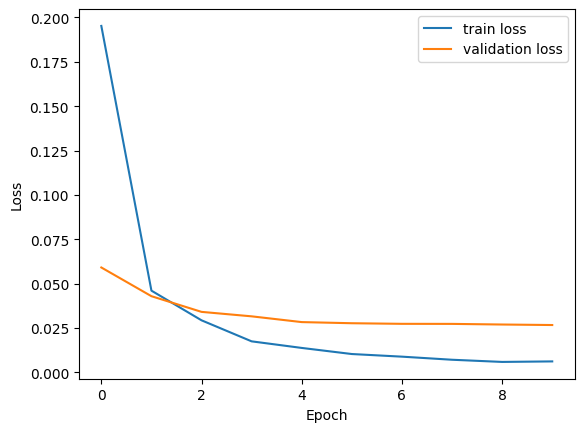

In [26]:
plot_losses(saved_losses)

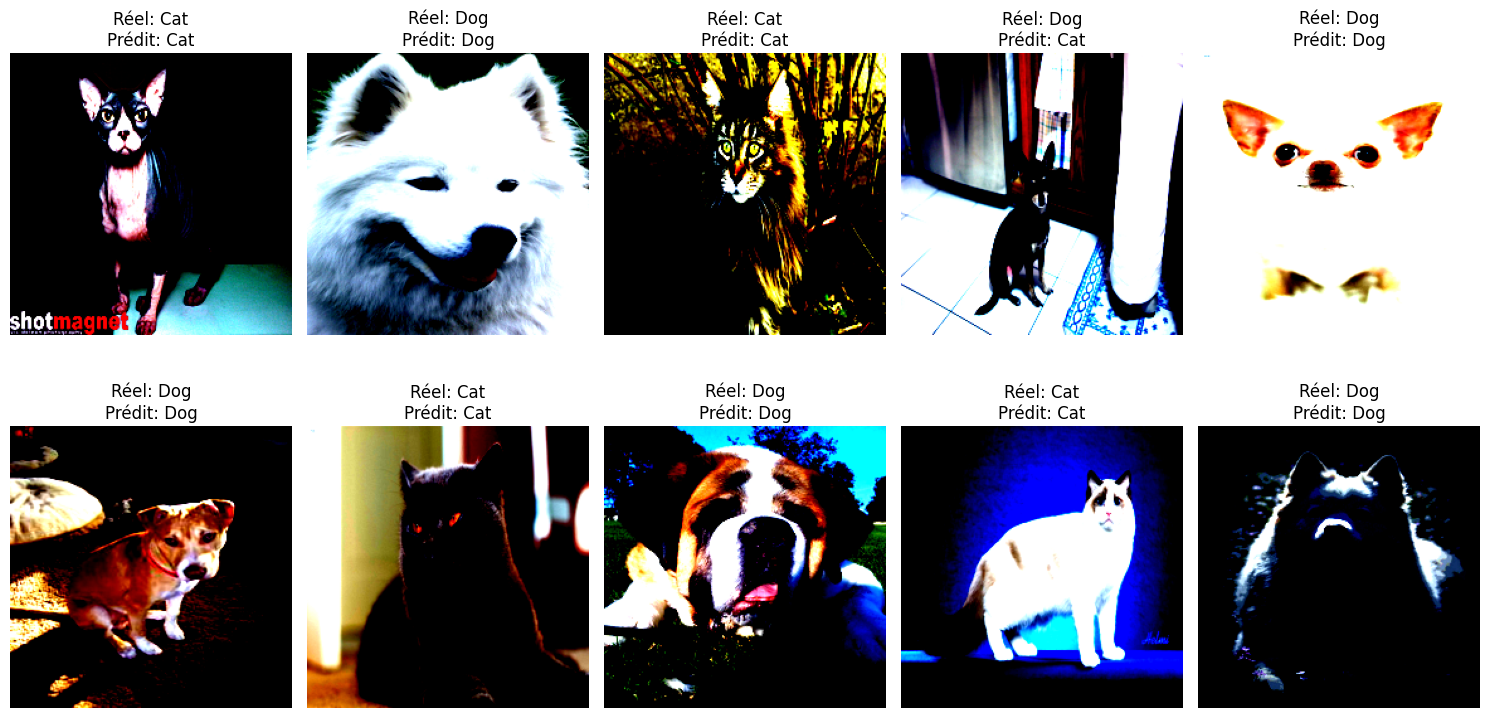

In [27]:
def plot_val_images(model, test_loader, class_names, device, n_images=10):
    """
    Affiche n_images du test_loader avec labels réels et labels prédits.
    """
    model.eval()
    idxs = np.random.choice(len(test_dataset), n_images, replace=False)
    images, labels, preds = [], [], []
    for i in range(n_images):
        idx = idxs[i]
        image, label = test_dataset[idx]
        image = image.to(device).unsqueeze(0)
        with torch.no_grad():
            output = model(image)
            _, pred = torch.max(output, 1)
        images.append(image.squeeze(0).cpu())
        labels.append(label)
        preds.append(pred.item())

    plt.figure(figsize=(15, 8))
    for i, idx in enumerate(idxs):
        ax = plt.subplot(2, n_images//2, i+1)
        img = images[i].permute(1,2,0).numpy()
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f"Réel: {class_names[labels[i]]}\nPrédit: {class_names[preds[i]]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_val_images(model_ft, test_loader, dataset.bin_classes, device, n_images=10)

### Part 2 : Classification - Fine-tuning de ResNet réutilisé
License BSD Code adapté du tuto Torch de transfer learning

In [28]:
num_classes = 37 # classification par races
class_names = dataset.classes

batch_size = 60
num_epochs = 10 
learning_rate = 0.001

img_width, img_height = 224, 224 # recommandé pour VGG16, taille de IMAGENET dataset ayant entrainé vgg16
size = (img_width, img_height)

train_dataset, test_dataset, train_loader, test_loader = get_datasets_loaders(batch_size, target_types="category", size=size, norm_like_ImageNet=False)
dataloaders = {'train': train_loader, 'val': test_loader}
dataset_sizes = {'train' : len(train_dataset) , 'val': len(test_dataset)}

In [29]:
model_ft2 = models.resnet18(weights='IMAGENET1K_V1')  # pré-entrainé sur ImageNet
num_ftrs = model_ft2.fc.in_features

model_ft2.fc = nn.Linear(num_ftrs, num_classes) # modification de la dernière couche du modèle pour l'adaper au nombre de classes

model_ft2 = model_ft2.to(device)

criterion = nn.CrossEntropyLoss()

# Ici on optimise tous les paramètres du modèle
optimizer_ft = optim.SGD(model_ft2.parameters(), lr=learning_rate, momentum=0.9)

# Le learning rate est divisé par 10 au bout de chaque période de 7 epochs, cela affine l'apprentissage au fur et à mesure
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [30]:
model_ft2, saved_losses = train_schdl(model_ft2, 
                        dataloaders, 
                        dataset_sizes, 
                        criterion, 
                        optimizer_ft, 
                        exp_lr_scheduler,
                        path='model_ft_calsses.pt',
                        num_epochs=num_epochs)

Epoch 0/9
----------
train Loss: 2.9460 Acc: 0.3264
val Loss: 1.8438 Acc: 0.6797

Epoch 1/9
----------
train Loss: 1.3715 Acc: 0.8005
val Loss: 1.0148 Acc: 0.8302

Epoch 2/9
----------
train Loss: 0.7900 Acc: 0.8872
val Loss: 0.7237 Acc: 0.8613

Epoch 3/9
----------
train Loss: 0.5547 Acc: 0.9152
val Loss: 0.5959 Acc: 0.8705

Epoch 4/9
----------
train Loss: 0.4189 Acc: 0.9367
val Loss: 0.5360 Acc: 0.8763

Epoch 5/9
----------
train Loss: 0.3320 Acc: 0.9514
val Loss: 0.4865 Acc: 0.8814

Epoch 6/9
----------
train Loss: 0.2694 Acc: 0.9685
val Loss: 0.4611 Acc: 0.8888

Epoch 7/9
----------
train Loss: 0.2287 Acc: 0.9761
val Loss: 0.4493 Acc: 0.8907

Epoch 8/9
----------
train Loss: 0.2246 Acc: 0.9766
val Loss: 0.4456 Acc: 0.8918

Epoch 9/9
----------
train Loss: 0.2236 Acc: 0.9780
val Loss: 0.4451 Acc: 0.8902

Training complete in 6m 1s
Best val Acc: 0.891796


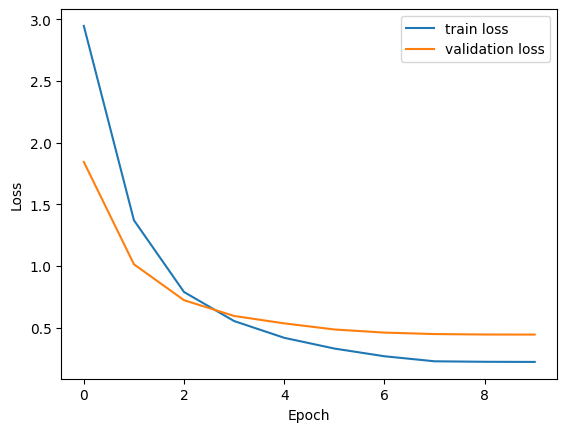

In [31]:
plot_losses(saved_losses)

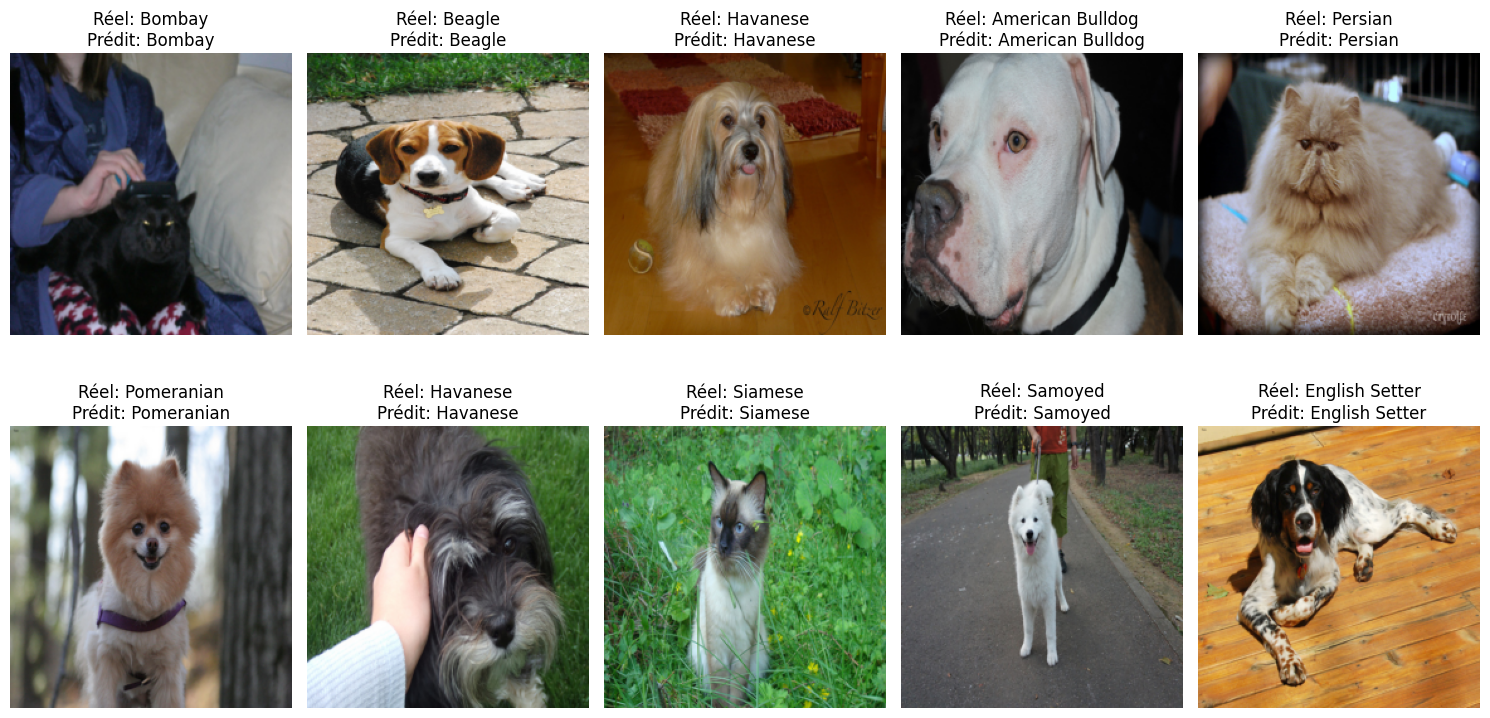

In [32]:
plot_val_images(model_ft2, test_loader, dataset.classes, device, n_images=10)

In [33]:
# fonction pour calculer les performances du modèles selon les races de chats et de chiens

def evaualte_model_by_classes(model, test_loader, class_names, device):
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    from sklearn.metrics import classification_report
    print(classification_report(all_labels, all_preds, target_names=class_names))

evaualte_model_by_classes(model_ft2, test_loader, dataset.classes, device)

                            precision    recall  f1-score   support

                Abyssinian       0.84      0.86      0.85        98
          American Bulldog       0.70      0.93      0.80       100
 American Pit Bull Terrier       0.71      0.50      0.59       100
              Basset Hound       0.94      0.91      0.92       100
                    Beagle       0.84      0.92      0.88       100
                    Bengal       0.76      0.90      0.82       100
                    Birman       0.79      0.84      0.81       100
                    Bombay       0.94      0.99      0.96        88
                     Boxer       0.77      0.93      0.84        99
         British Shorthair       0.97      0.84      0.90       100
                 Chihuahua       0.91      0.80      0.85       100
              Egyptian Mau       0.94      0.86      0.90        97
    English Cocker Spaniel       0.92      0.90      0.91       100
            English Setter       0.93      0.91

Les catégorie pour lesquelles le modèle est moins bon sont Bombay, Abyssinian et Egyptian Mau. Ce sont trois race de chats au poils courts avec des oreilles triangles.

## Part 3: U-net from scratch pour Segmenter nos images

source : https://debuggercafe.com/unet-from-scratch-using-pytorch/ documentation torch


In [34]:
batch_size = 16
size = (64, 64)  # taille des images redimensionnées

train_dataset, test_dataset, train_loader, test_loader = get_datasets_loaders(batch_size, target_types="segmentation", size=size, norm_like_ImageNet=False)
dataloaders = {'train': train_loader, 'val': test_loader}
dataset_sizes = {'train' : len(train_dataset) , 'val': len(test_dataset)}

Définition du modèle Unet utilisé, nous en utiliserons un peu profond pour ne pas avoir de trop grandes durées d'entrainement, de plus ses résultats sont assez bons

In [35]:
def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )

class UNetSmall(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.down1 = double_conv(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = double_conv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = double_conv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = double_conv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv3 = double_conv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = double_conv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = double_conv(64, 32)

        self.out = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        bn = self.bottleneck(p3)

        u3 = self.up3(bn)
        c3 = self.conv3(torch.cat([u3, d3], dim=1))
        u2 = self.up2(c3)
        c2 = self.conv2(torch.cat([u2, d2], dim=1))
        u1 = self.up1(c2)
        c1 = self.conv1(torch.cat([u1, d1], dim=1))

        out = self.out(c1)
        return out

La fonction d'entrainement pour le Unet renvoie également un dictionnaire contenant les losses d'entrainement et de validation, le modèle est enregistré en local

In [36]:
def train_unet(model, dataloaders, dataset_sizes, optimizer, criterion, num_epochs, path, device='cuda'):

    model.to(device)
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            running_loss = 0.0

            with torch.set_grad_enabled(phase == 'train'):
                for imgs, masks in dataloaders[phase]:

                    imgs = imgs.to(device)
                    masks = masks.to(device)
                    # squeeze le mask si besoin (normalement il n'y en a plus besoin)
                    if masks.ndim == 4 and masks.shape[1] == 1:
                        masks = masks.squeeze(1)

                    if phase == 'train':
                        optimizer.zero_grad()
                    outputs = model(imgs)
                    loss = criterion(outputs, masks.long()) # CrossEntropy est appliquée à des masks composés de valeurs entières (ici 0, 1, 2)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                    running_loss += loss.item() * imgs.size(0)

            epoch_loss = running_loss / dataset_sizes[phase]

            if phase == 'train':
                train_losses.append(epoch_loss)
            else:
                val_losses.append(epoch_loss)

            print(f"{phase} Loss: {epoch_loss:.4f}")
            
    saved_losses = {'train': train_losses, 'val': val_losses}        
    path_model = path
    torch.save(model.state_dict(), path_model)

    return model, saved_losses

La fonction affichant les résultats de la segmentation permet également l'affichage des IoUs s'ils ont étés calculés.

In [37]:
def plot_segmentation_results(model, dataset, device='cuda', num_images=3, idxs_liste=[], IoU=None):
    """_cette fonction affiche num_images du dataset, les masques réels et les masques prédits, si les IoU ont étés calculés il est possible de les afficher en titre des masques prédits_

    Args:
        model : unet on device
        dataset : dataset d'où les images sont extraites (en génral on choisit test_dataset)
        device (str, optional): . Defaults to 'cuda'.
        num_images (int, optional): nombre d'images. Defaults to 3.
        idxs_liste (list, optional): listes des indices des images à afficher . Defaults to [].
        IoU (dict, optional): IoUs calculés sur la liste des images à afficher, dictionnaire pour chacune des trois catégories (animal, background, limite). Defaults to None.
    """
    model.eval()
    fig, axes = plt.subplots(num_images, 3, figsize=(8, 2 * num_images))

    idxs = list(range(num_images))

    if idxs_liste:
        idxs = idxs_liste

    for i in range(num_images):
        
        idx = idxs[i]
        img, mask = dataset[idx]
        img_input = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img_input)
            pred_mask = torch.argmax(output.squeeze(0), dim=0).cpu()

        axes[i, 0].imshow(torch.permute(img, (1, 2, 0)))
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(mask.squeeze(), cmap="Set3")
        axes[i, 1].set_title("Masque réel")
        axes[i, 1].axis("off")
        axes[i, 2].imshow(pred_mask, cmap="Set3")
        axes[i, 2].set_title("Prédiction")
        if IoU:
            animals, background, limite = IoU['animal'][i], IoU['background'][i], IoU['limite'][i]
            axes[i, 2].set_title(f"IoU:\nanimal {animals:.4f}\nbackground {background:.4f}\nlimite {limite:.4f}")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

- Nous choisissons une fonction de Cross Entropy pour la loss car il s'agit d'une tâche de classification.
- L'optimiseur Adam donne de bons résultats.
- Le learning rate est choisi faible.

Epoch 1/20
train Loss: 0.7899
val Loss: 0.7380
Epoch 2/20
train Loss: 0.6778
val Loss: 0.6380
Epoch 3/20
train Loss: 0.6211
val Loss: 0.6060
Epoch 4/20
train Loss: 0.5624
val Loss: 0.5634
Epoch 5/20
train Loss: 0.5123
val Loss: 0.4889
Epoch 6/20
train Loss: 0.4820
val Loss: 0.4634
Epoch 7/20
train Loss: 0.4572
val Loss: 0.4432
Epoch 8/20
train Loss: 0.4300
val Loss: 0.4324
Epoch 9/20
train Loss: 0.4124
val Loss: 0.4271
Epoch 10/20
train Loss: 0.3961
val Loss: 0.4748
Epoch 11/20
train Loss: 0.3876
val Loss: 0.4189
Epoch 12/20
train Loss: 0.3728
val Loss: 0.4018
Epoch 13/20
train Loss: 0.3518
val Loss: 0.3916
Epoch 14/20
train Loss: 0.3337
val Loss: 0.3879
Epoch 15/20
train Loss: 0.3267
val Loss: 0.4007
Epoch 16/20
train Loss: 0.3160
val Loss: 0.4275
Epoch 17/20
train Loss: 0.3056
val Loss: 0.4150
Epoch 18/20
train Loss: 0.2933
val Loss: 0.4143
Epoch 19/20
train Loss: 0.2822
val Loss: 0.4052
Epoch 20/20
train Loss: 0.2604
val Loss: 0.4110


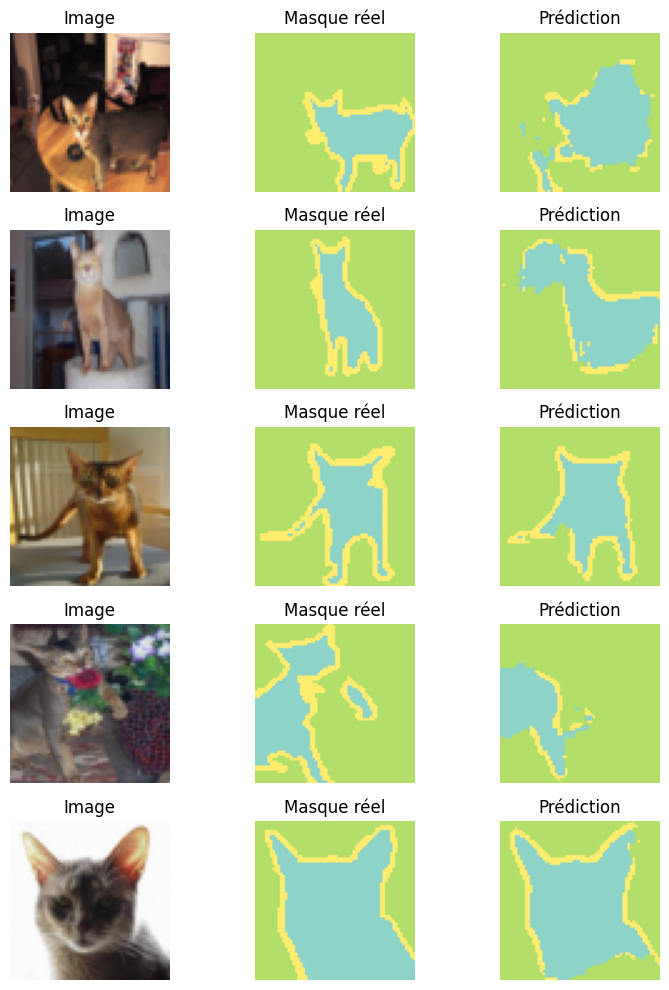

In [38]:
# Initialisation du modèle, optimizer et loss
num_classes = 3  # animal, background et limite
model = UNetSmall(num_classes=num_classes)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss() # la CrossEntropy (tâche de classification en 3 catégories)
num_epochs = 20

# Entraînement du modèle
model, saved_losses = train_unet(model,
                                 dataloaders,
                                 dataset_sizes,
                                 optimizer,
                                 criterion,
                                 num_epochs,
                                 path = 'unet_small_model.pt',
                                 device=device)

# Visualisations sur l'ensemble de validation
plot_segmentation_results(model, dataloaders['val'].dataset, device=device, num_images=5)

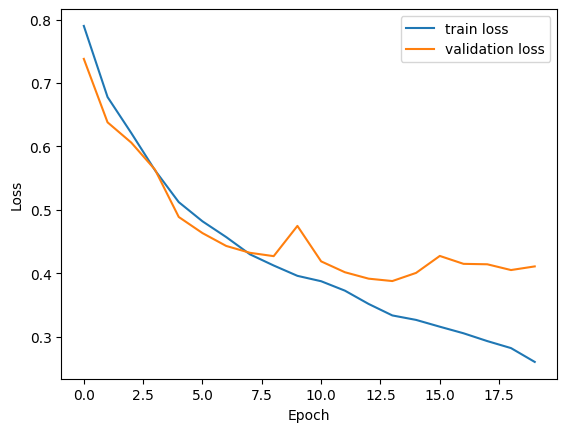

In [39]:
plot_losses(saved_losses)

Afin de ne pas avoir à réentrainer le modèle tous les jours, nous le stockons en local au path spécifié en argument de la fonction d'apprentissage

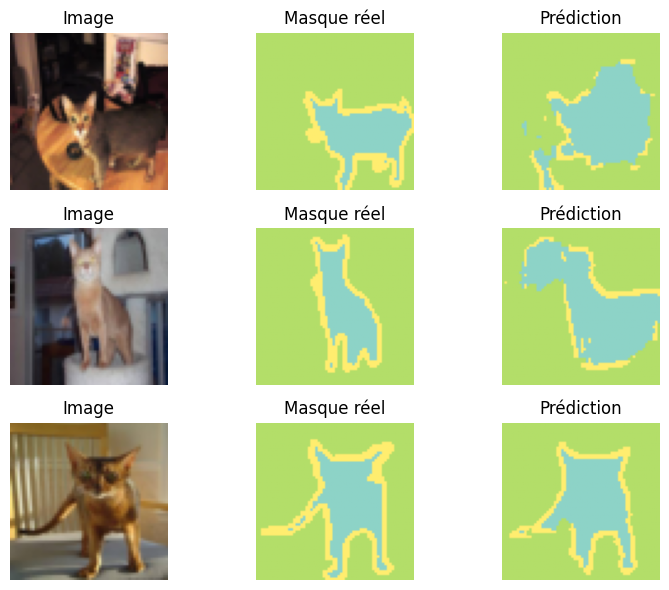

In [40]:
num_classes = 3  # animal, fond, limite
path = 'unet_small_model.pt'

model = UNetSmall(num_classes=num_classes)

model.load_state_dict(torch.load(path, weights_only=True, map_location=device))
model = model.to(device)

plot_segmentation_results(model, test_dataset, device=device, num_images=3)

Pour comparer les masques prévus et réels, une fonction générique est définie servant à en extraire <i>num_images</i> dans le dataset choisi (souvent le dataset de test).

In [41]:
def get_true_and_output_masks(model, dataset, num_images, random_idxs = []):

    model.eval()
    true_masks = []
    output_masks = []

    idxs = np.random.choice(len(dataset), num_images, replace=False)

    if random_idxs:
        idxs = random_idxs

    for idx in idxs:
        img, mask = dataset[idx]
        img_input = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img_input)
            pred_mask = torch.argmax(output.squeeze(0), dim=0).cpu()

        true_masks.append(mask)
        output_masks.append(pred_mask)

    return true_masks, output_masks

#### IoU : Intersection over Union
Les IoUs sont calculés et sont affichés au dessus du masque de segmentation prévu.

In [42]:
# FONCTION DE CALCUL DES IoU pour un masque réel et un masque prédit donnés
def IoU_segmentation(output_mask, true_mask, num_classes):

    IoUs = []

    for classe in range(num_classes):
        pred_inds = (output_mask == classe) # masque prédit pour la classe (True values)
        target_inds = (true_mask == classe) # masque réel pour la classe (True values)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            IoUs.append(float('nan'))  # Classe absente dans les deux masques
        else:
            IoUs.append(intersection / union)

    return IoUs

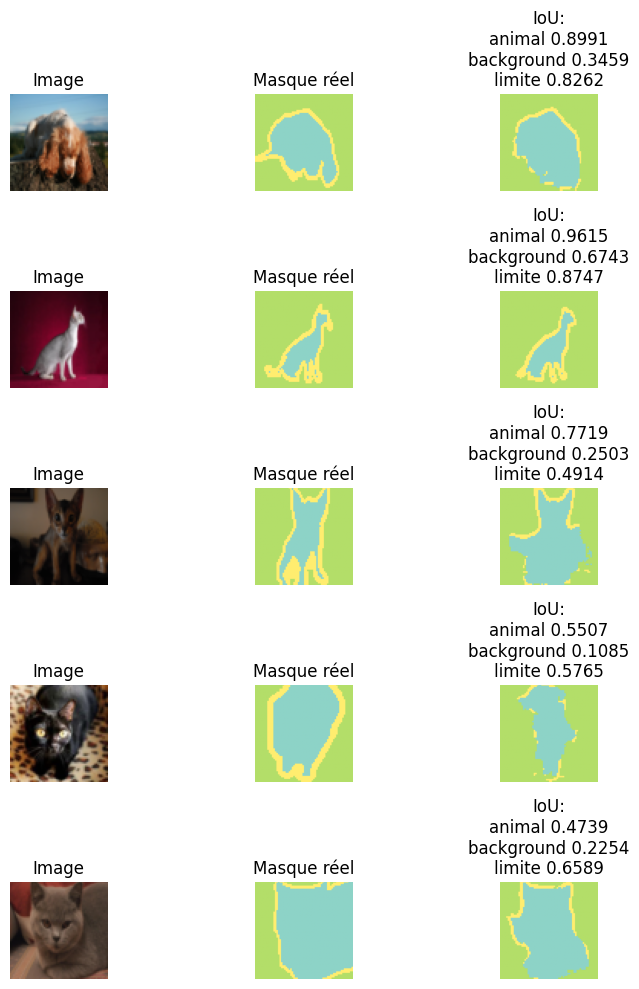

In [43]:
num_images = 5
dataset = test_dataset
n_dataset = len(dataset)
random_idxs = list(np.random.choice(range(n_dataset), num_images, replace = False))
random_idxs = [1200, 34, 56, 708, 900] # 2000 est plus ou moins la limite entre chats et chiens dans le dataset

true_masks, output_masks = get_true_and_output_masks(model, test_dataset, num_images=num_images, random_idxs=random_idxs)

IoU_scores = {'animal': [], 'background': [], 'limite': []}

for i in range(num_images):

    IoU = IoU_segmentation(output_masks[i], true_masks[i], num_classes=3)

    IoU_scores['animal'].append(IoU[1]) 
    IoU_scores['background'].append(IoU[2])  
    IoU_scores['limite'].append(IoU[0])  

plot_segmentation_results(model, test_dataset, device=device, num_images=num_images, idxs_liste=random_idxs, IoU=IoU_scores)

#### Dice-Sørensen coefficient
To gauge the similarity of two samples

In [44]:
# FONCTION DE CALCUL DES DICE pour un masque réel et un masque prédit donnés
def DICE_segmentation(output_mask, true_mask, num_classes):

    DICEs = []

    for classe in range(num_classes):
        pred_inds = (output_mask == classe) # masque prédit pour la classe (True values)
        target_inds = (true_mask == classe) # masque réel pour la classe (True values)

        intersection = (pred_inds & target_inds).sum().item()
        size_sum = pred_inds.sum().item() + target_inds.sum().item()

        if size_sum == 0:
            DICEs.append(float('nan'))  # Classe absente dans les deux masques
        else:
            DICEs.append((2 * intersection) / size_sum)

    return DICEs

#### Comparaison des performances de segmentation entre chats et chiens

In [45]:
n_cats = 1181
n_dogs = 2488

from torch.utils.data import Subset

# Indices des chats et des chiens
indices_cats = list(range(n_cats + 1))
indices_dogs = list(range(n_cats + 1, len(test_dataset)))

dataset_cats = Subset(test_dataset, indices_cats)
dataset_dogs = Subset(test_dataset, indices_dogs)

In [46]:
num_classes = 3
num_images = 1000

random_idxs = list(np.random.choice(range(1000), num_images, replace = False))

true_masks_cats, output_masks_cats = get_true_and_output_masks(model, dataset_cats, num_images=num_images, random_idxs=random_idxs)
true_masks_dogs, output_masks_dogs = get_true_and_output_masks(model, dataset_dogs, num_images=num_images, random_idxs=random_idxs)

def compute_average_IoU_DICE(true_masks, output_masks, num_classes):

    classes = ['animal', 'background', 'limite']
    
    IoU_scores = {f'{classes[i]}': [] for i in range(num_classes)}
    DICE_scores = {f'{classes[i]}': [] for i in range(num_classes)}

    for i in range(num_images):

        IoU = IoU_segmentation(output_masks[i], true_masks[i], num_classes)
        DICE = DICE_segmentation(output_masks[i], true_masks[i], num_classes)

        for j in range(num_classes):
            classe = classes[j]
            IoU_scores[f'{classe}'].append(IoU[j])
            DICE_scores[f'{classe}'].append(DICE[j])

    avg_IoU = {}
    avg_DICE = {}
    for classe in classes:        
        # Calcul des moyennes
        avg_IoU[classe] = np.nanmean(IoU_scores[classe]) # nan au cas ou une classe ne soit pas représentée dans l'image (nan)
        avg_DICE[classe] = np.nanmean(DICE_scores[classe]) 

    return avg_IoU, avg_DICE, IoU_scores, DICE_scores

In [47]:
avg_IoU_cats, avg_DICE_cats, IoU_scores_cats, DICE_scores_cats = compute_average_IoU_DICE(true_masks_cats, output_masks_cats, num_classes)
avg_IoU_dogs, avg_DICE_dogs, IoU_scores_dogs, DICE_scores_dogs = compute_average_IoU_DICE(true_masks_dogs, output_masks_dogs, num_classes)

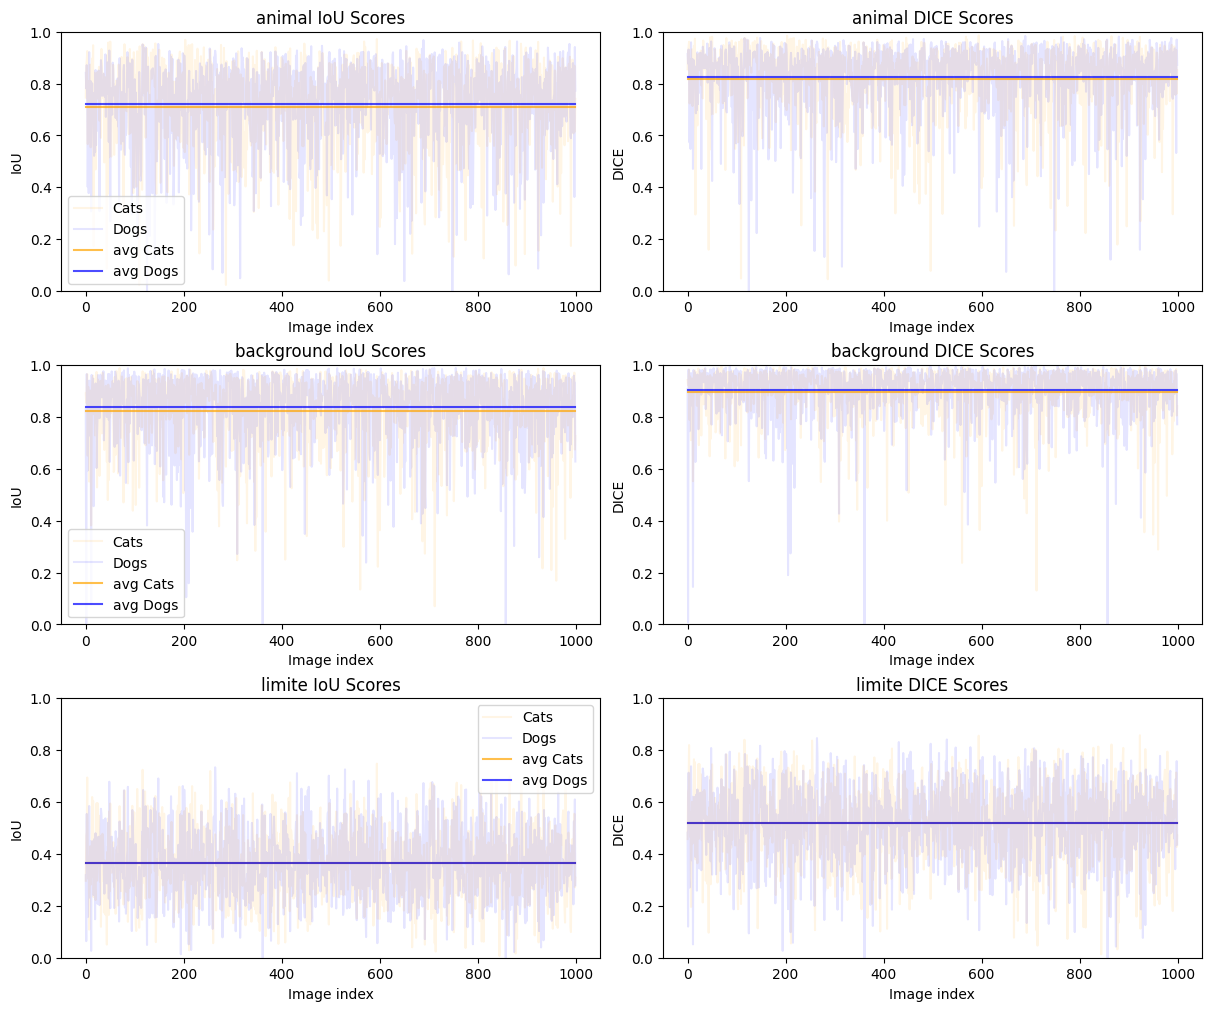

In [48]:
fig, axs = plt.subplots(3, 2, figsize=(12, 10), layout='constrained')
classes =['animal', 'background', 'limite']
for i in range(num_classes):
    classe = classes[i]
    axs[i,0].plot(np.arange(num_images),IoU_scores_cats[classe], alpha=0.1, label='Cats', color='orange')
    axs[i,0].plot(np.arange(num_images),IoU_scores_dogs[classe], alpha=0.1, label='Dogs', color='blue')
    axs[i,0].plot(np.arange(num_images),[avg_IoU_cats[classe] for _ in range(num_images)], alpha=0.7, label='avg Cats', color='orange')
    axs[i,0].plot(np.arange(num_images),[avg_IoU_dogs[classe] for _ in range(num_images)], alpha=0.7, label='avg Dogs', color='blue')
    axs[i,0].set_title(f'{classe} IoU Scores')
    axs[i,0].set_ylabel('IoU')
    axs[i,0].set_xlabel('Image index')
    axs[i,0].set_ylim(0,1)
    axs[i,0].legend()
    axs[i,1].plot(np.arange(num_images),DICE_scores_cats[classe], alpha=0.1, label='Cats', color='orange')
    axs[i,1].plot(np.arange(num_images),DICE_scores_dogs[classe], alpha=0.1, label='Dogs', color='blue')
    axs[i,1].plot(np.arange(num_images),[avg_DICE_cats[classe] for _ in range(num_images)], alpha=0.7, label='avg Cats', color='orange')
    axs[i,1].plot(np.arange(num_images),[avg_DICE_dogs[classe] for _ in range(num_images)], alpha=0.7, label='avg Dogs', color='blue')
    axs[i,1].set_title(f'{classe} DICE Scores')
    axs[i,1].set_ylabel('DICE')
    axs[i,1].set_xlabel('Image index')
    axs[i,1].set_ylim(0,1)


Remarques sur les scores :
- Les IoU et les DICE sont légèrement meilleurs pour les chiens que pour les chats (lors de la segmentation de l'animal). la même remarque pourrait se faire sur le background mais il faut garder à l'esprit que la variabilité de ces indices d'une image à l'autre est très grande, ce qui modère les conclusions que l'on peut tirer de la moyenne.
- En étudiant les IoUs, on remarque que le background est le mieux prévu, ensuite l'animal et enfin les limites de celui-ci. C'est assez logique, les limites étant plus fines.  

#### Documentation

- Fine tuning VGG16 : https://medium.com/@qakunnath/fine-tuning-a-pre-trained-vgg16-model-for-custom-image-classification-b1fd4bf56aad
- Fine tuning VGG16 : https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.vgg16.html
- Fine tuning ResNet18 : https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html

- Torch tutorials pour le fine tuning : https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html
- Torch tutorials pour le fine tuning : https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html